# Why Sigmoid Hurts Deep Networks — The Vanishing Gradient Problem

Around 2012, deep learning had a breakthrough that wasn't a clever new algorithm. It was **swapping one function for another**: sigmoid → ReLU. Suddenly networks that wouldn't train, trained.

Why? Because of something called the **vanishing gradient problem**. We're going to build intuition for it from four angles, without any chain rule.

### The telephone game

Training a neural network is a game of **"pass the correction backward"**. When the network makes a wrong prediction, a correction signal has to travel from the **output layer back to the input layer**, telling every weight how to adjust itself.

It's like the telephone game: a message is whispered from person to person. If each person whispers slightly quieter than they heard, after 10 people the message is gone. The first person in line hears nothing and can't act on it.

The "quieter whisper" in a neural network is what happens to the gradient when it passes through an activation function. And this is where sigmoid and ReLU behave very differently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

torch.manual_seed(0)
np.random.seed(0)

---
## Angle 1 — The Slope is the Volume Knob

Here's the key fact, without any calculus:

> When the correction signal passes backward through an activation function, it gets **multiplied by the slope of that activation** at the current point.

So the slope acts like a **volume knob**. A slope of 1 = full volume. A slope of 0.5 = half volume. A slope of 0 = silence.

Let's look at what slope each activation actually provides.

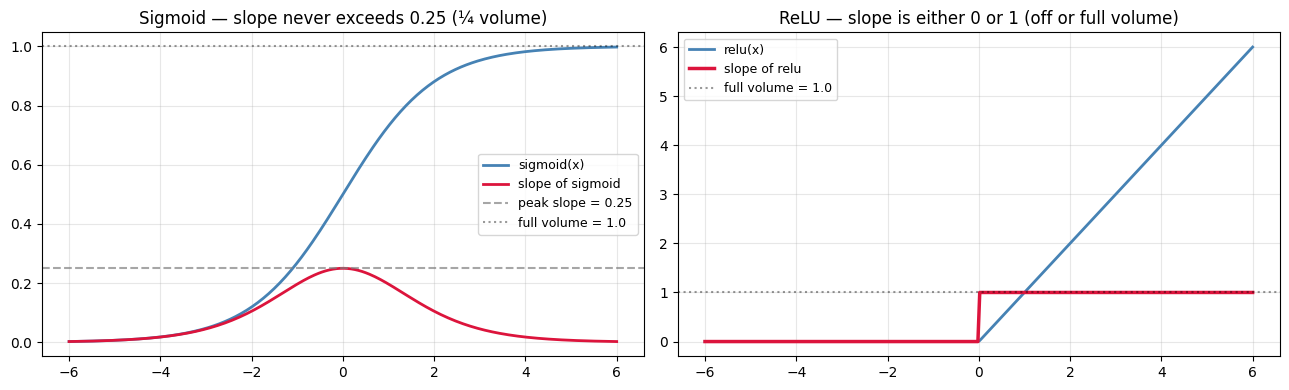

In [2]:
x = torch.linspace(-6, 6, 300)
sig = torch.sigmoid(x);  sig_slope  = sig * (1 - sig)
relu = torch.relu(x);    relu_slope = (x > 0).float()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, sig, label='sigmoid(x)', color='steelblue', linewidth=2)
axes[0].plot(x, sig_slope, label='slope of sigmoid', color='crimson', linewidth=2)
axes[0].axhline(0.25, color='gray', linestyle='--', alpha=0.7, label='peak slope = 0.25')
axes[0].axhline(1.0,  color='black', linestyle=':', alpha=0.4, label='full volume = 1.0')
axes[0].set_title("Sigmoid — slope never exceeds 0.25 (¼ volume)")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)

axes[1].plot(x, relu, label='relu(x)', color='steelblue', linewidth=2)
axes[1].plot(x, relu_slope, label='slope of relu', color='crimson', linewidth=2.5)
axes[1].axhline(1.0, color='black', linestyle=':', alpha=0.4, label='full volume = 1.0')
axes[1].set_title("ReLU — slope is either 0 or 1 (off or full volume)")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

**The headline:**

- **Sigmoid's volume knob is broken.** At its *best*, it only lets **25%** of the signal through. It can never pass a signal at full strength.
- **ReLU's knob is binary.** Either the neuron is active → full volume (slope = 1), or it's off → silence (slope = 0). No in-between shrinking.

So at every sigmoid layer, the signal drops to at most a quarter of what came in. At every active ReLU layer, the signal passes through untouched.

---
## Angle 2 — Small Numbers, Multiplied Many Times, Vanish Fast

One sigmoid layer cutting the signal to 25% isn't catastrophic. The catastrophe is that networks are **deep**. The signal passes through many layers on its way back to the first layer, and each one multiplies by the volume factor.

After $N$ sigmoid layers, the signal is multiplied by at most $0.25^N$. Let's see what that looks like.

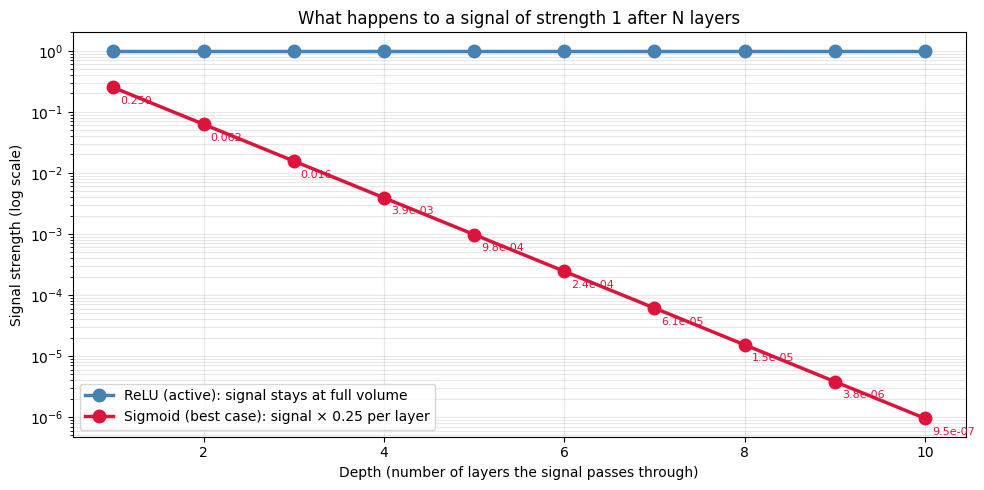

In [3]:
depths = np.arange(1, 11)
sigmoid_best = 0.25 ** depths               # optimistic: every layer at peak slope
relu_always  = np.ones_like(depths, dtype=float)  # every active ReLU passes it through

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, relu_always,  'o-', color='steelblue', linewidth=2.5,
        markersize=9, label='ReLU (active): signal stays at full volume')
ax.plot(depths, sigmoid_best, 'o-', color='crimson', linewidth=2.5,
        markersize=9, label='Sigmoid (best case): signal × 0.25 per layer')

# Annotate the sigmoid numbers — they're brutal
for d, s in zip(depths, sigmoid_best):
    ax.annotate(f'{s:.1e}' if s < 0.01 else f'{s:.3f}',
                (d, s), xytext=(5, -12), textcoords='offset points',
                fontsize=8, color='crimson')

ax.set_yscale('log')
ax.set_xlabel('Depth (number of layers the signal passes through)')
ax.set_ylabel('Signal strength (log scale)')
ax.set_title("What happens to a signal of strength 1 after N layers")
ax.grid(alpha=0.3, which='both'); ax.legend()
plt.tight_layout(); plt.show()

Read the red line. By the time a signal has traveled back through just **5 sigmoid layers**, it's been reduced to about **0.1%** of its original strength — even in the best case. After 10 layers, it's a one-in-a-million fraction. The first layer receives a whisper of a whisper of a whisper.

This is why training deep sigmoid networks was **so hard** before 2012. It wasn't that people weren't trying — it's that the gradient literally evaporated before it reached the early layers.

And remember: **this is the best case.** The actual slope is often much smaller than 0.25. That's Angle 3.

---
## Angle 3 — Saturation Makes it Far Worse

Sigmoid's slope is 0.25 **only at $x = 0$**. Move even a little bit away from zero, and the slope drops off a cliff.

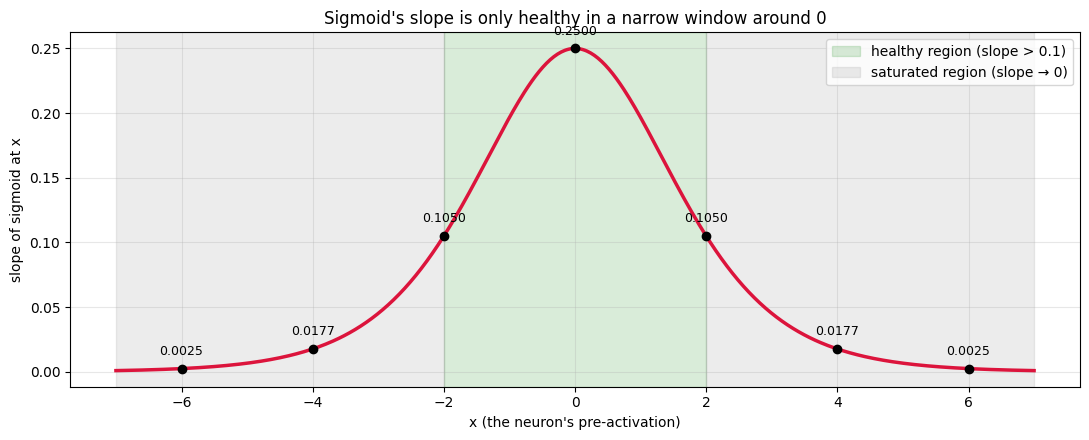

In [4]:
x = torch.linspace(-7, 7, 500)
sig_slope = torch.sigmoid(x) * (1 - torch.sigmoid(x))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x, sig_slope, color='crimson', linewidth=2.5)

# Shade the "healthy" vs "saturated" regions
ax.axvspan(-2, 2, alpha=0.15, color='green', label='healthy region (slope > 0.1)')
ax.axvspan(-7, -2, alpha=0.15, color='gray')
ax.axvspan(2, 7, alpha=0.15, color='gray', label='saturated region (slope → 0)')

# Mark specific slope values at specific x
for xv in [-6, -4, -2, 0, 2, 4, 6]:
    yv = float(torch.sigmoid(torch.tensor(xv)) * (1 - torch.sigmoid(torch.tensor(xv))))
    ax.plot([xv], [yv], 'ko', markersize=6)
    ax.annotate(f'{yv:.4f}', (xv, yv), xytext=(0, 10),
                textcoords='offset points', fontsize=9, ha='center')

ax.set_xlabel('x (the neuron\'s pre-activation)')
ax.set_ylabel('slope of sigmoid at x')
ax.set_title("Sigmoid's slope is only healthy in a narrow window around 0")
ax.grid(alpha=0.3); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

Look at the numbers next to each dot:

| Neuron input $x$ | Sigmoid slope | Volume |
|---|---|---|
| 0 | 0.25 | 25% (best case) |
| ±2 | 0.105 | 10.5% |
| ±4 | 0.018 | 1.8% |
| ±6 | 0.0025 | 0.25% |

In practice, as training progresses, neuron inputs routinely grow beyond ±2. Once that happens, the neuron is said to be **saturated** — its output is "stuck" near 0 or 1, and its slope is nearly zero.

So the compounding effect from Angle 2, with its optimistic $0.25^N$, is actually far worse in practice. A real deep sigmoid network might be multiplying by $0.05$ or $0.01$ at each layer.

And that's why, empirically:

---
## Angle 4 — See it Happen in a Real 6-Layer Network

Enough theory. Let's train two identical 6-layer networks on the moons dataset. Same architecture, same initialization, same data, same learning rate. The **only** difference: one uses sigmoid, the other uses ReLU.

We'll track two things:
1. The **gradient norm at each layer** — how much signal is reaching each layer's weights.
2. The **training loss** — whether the network actually learns anything.

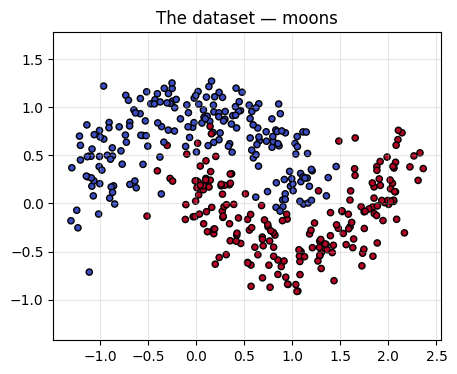

In [5]:
X, y = make_moons(n_samples=400, noise=0.20, random_state=42)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
plt.title("The dataset — moons"); plt.axis('equal'); plt.grid(alpha=0.3); plt.show()

### The network

Six hidden layers of 32 neurons each, then an output layer. We'll store layers in a `ModuleList` so we can easily grab each one's gradient after a backward pass.

In [12]:
class DeepNet(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(2, 32),    # layer 0 — closest to input
            nn.Linear(32, 32),   # layer 1
            nn.Linear(32, 32),   # layer 2
            nn.Linear(32, 32),   # layer 3
            nn.Linear(32, 32),   # layer 4
            nn.Linear(32, 32),   # layer 5
            nn.Linear(32, 2),    # layer 6 — output, closest to loss
        ])
        self.act = activation_fn

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.act(layer(x))
        return self.layers[-1](x)

In [ ]:
2,32

### Training loop that tracks everything

For each step, we record:
- the loss (to plot a learning curve)
- the gradient norm of **every** layer's weights (to plot signal strength per layer)

In [13]:
model = DeepNet(torch.relu)

for i, layer in enumerate(model.layers):
        print(layer.weight.shape)


torch.Size([32, 2])
torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([2, 32])


In [ ]:
def train_and_track(activation_fn, steps=800, lr=0.1):
    torch.manual_seed(0)                   # same init for fair comparison
    model = DeepNet(activation_fn)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    grads_per_layer = [[] for _ in range(7)]

    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        losses.append(loss.item())
        for i, layer in enumerate(model.layers):
            grads_per_layer[i].append(layer.weight.grad.norm().item())
        opt.step()

    acc = (model(X_t).argmax(1) == y_t).float().mean().item()
    return losses, grads_per_layer, acc

sig_losses, sig_grads, sig_acc = train_and_track(torch.sigmoid)
relu_losses, relu_grads, relu_acc = train_and_track(torch.relu)

print(f"Sigmoid net: final loss = {sig_losses[-1]:.4f}, accuracy = {sig_acc:.1%}")
print(f"ReLU net:    final loss = {relu_losses[-1]:.4f}, accuracy = {relu_acc:.1%}")

Sigmoid net: final loss = 0.6931, accuracy = 40.5%
ReLU net:    final loss = 0.0694, accuracy = 97.8%


### Plot 1 — Gradient strength at each layer

This is the smoking gun. One bar per layer, showing the size of the gradient signal that reached that layer. Layer 0 is the first layer (closest to input — where the signal is weakest), layer 6 is the output.

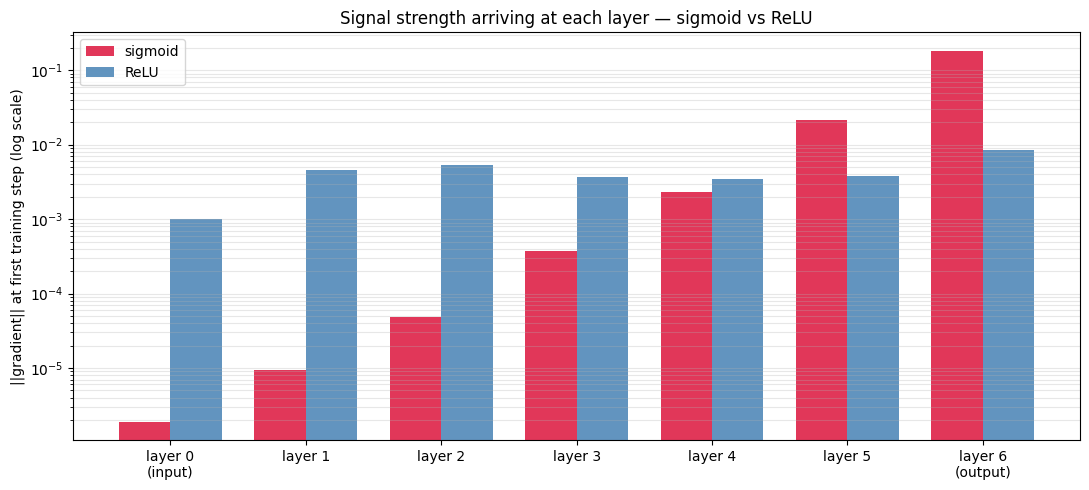


Sigmoid: last-layer grad is 95,427x larger than first-layer grad
ReLU:    last-layer grad is 8.4x larger than first-layer grad


In [11]:
# Gradient norm at the very first step — cleanest view of "what arrived"
sig_first_step = [g[0] for g in sig_grads]
relu_first_step = [g[0] for g in relu_grads]

layer_idx = np.arange(7)
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(layer_idx - width/2, sig_first_step, width, label='sigmoid',
       color='crimson', alpha=0.85)
ax.bar(layer_idx + width/2, relu_first_step, width, label='ReLU',
       color='steelblue', alpha=0.85)

ax.set_yscale('log')
ax.set_xticks(layer_idx)
ax.set_xticklabels([f'layer {i}\n(input)' if i == 0
                    else f'layer {i}\n(output)' if i == 6
                    else f'layer {i}' for i in layer_idx])
ax.set_ylabel('||gradient|| at first training step (log scale)')
ax.set_title("Signal strength arriving at each layer — sigmoid vs ReLU")
ax.legend(); ax.grid(alpha=0.3, axis='y', which='both')
plt.tight_layout(); plt.show()

print(f"\nSigmoid: last-layer grad is {sig_first_step[-1]/sig_first_step[0]:,.0f}x "
      f"larger than first-layer grad")
print(f"ReLU:    last-layer grad is {relu_first_step[-1]/relu_first_step[0]:.1f}x "
      f"larger than first-layer grad")

The effect is textbook-dramatic on a log scale:

- **Sigmoid**: the gradient at the output layer is roughly **100,000× larger** than at the input layer. The first layer is sitting in near-total darkness — it can't learn anything meaningful.
- **ReLU**: gradient is roughly the same order of magnitude across all 7 layers. Every layer gets a proper correction signal.

### Plot 2 — What this does to learning

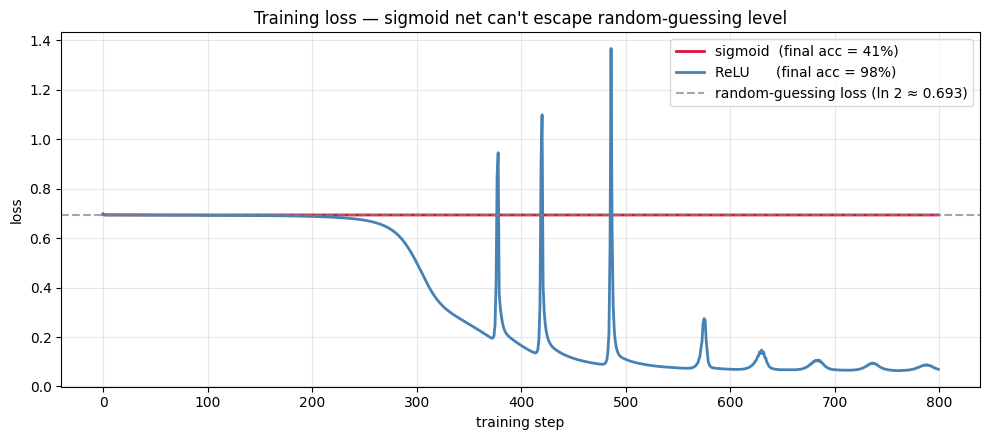

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(sig_losses, label=f'sigmoid  (final acc = {sig_acc:.0%})',
        color='crimson', linewidth=2)
ax.plot(relu_losses, label=f'ReLU      (final acc = {relu_acc:.0%})',
        color='steelblue', linewidth=2)
ax.axhline(np.log(2), color='gray', linestyle='--', alpha=0.7,
           label='random-guessing loss (ln 2 ≈ 0.693)')
ax.set_xlabel('training step')
ax.set_ylabel('loss')
ax.set_title("Training loss — sigmoid net can't escape random-guessing level")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The sigmoid network's loss is **glued to $\ln 2$** — that's the loss of a model that always predicts 50/50. It didn't learn *anything* in 800 steps. Its first-layer weights received gradients around $10^{-6}$, so the weights barely budged from their random initialization.

The ReLU network, on the other hand, drives the loss way down and hits ~97% accuracy. Same depth, same init, same data. The only difference is one Python function.

---
## A Fair Warning About ReLU

ReLU isn't perfect. It has its own failure mode, called **dead neurons**:

- If a ReLU neuron's input stays **negative**, its output is zero, and — critically — its **slope is also zero**.
- Slope zero means the volume knob is fully closed. No gradient flows through this neuron.
- No gradient means no weight update. The neuron is stuck at "always negative, always off" forever. Dead.

This is usually much less catastrophic than sigmoid's vanishing gradients — a few dead neurons in a big layer are survivable — but it's why variants like **Leaky ReLU** (which has a small slope for negative inputs) exist. You'll meet those later.

---
## Recap

Four angles, one core story:

1. **The slope of an activation acts as a volume knob** on the backward signal. Sigmoid caps at 25% per layer; ReLU is either 0% or 100%.
2. **Small multipliers compound** through depth. After 5 sigmoid layers at peak slope, the signal is at 0.1% — and that's the *best* case.
3. **Saturation makes it far worse.** Once a neuron's input drifts beyond ±2, its sigmoid slope drops below 10%. Real sigmoid networks during training multiply by much less than 0.25 at each layer.
4. **Empirically, in a 6-layer moons network**: the first layer's gradient is ~100,000× smaller with sigmoid than with ReLU. The sigmoid network fails to learn anything; the ReLU network hits 97%.

**Why this matters for your career:** this single insight unlocked modern deep learning. Every deep network you'll ever build uses a non-saturating activation in its hidden layers — ReLU, GELU, SiLU, or some cousin — for exactly the reasons we just saw.

**Things to experiment with:**
- Change the depth to 3 layers. Does sigmoid still fail? (Hint: it shouldn't — the problem is depth-dependent.)
- Swap `torch.sigmoid` for `torch.tanh`. Tanh has a peak slope of 1.0, not 0.25 — does it help?
- Change the initialization to something much smaller or much larger. Does ReLU start to struggle too?